# Lab: Statistics Basics

Statistics is the foundation underneath almost everything in data science and machine learning — from summarizing a dataset, to understanding relationships between variables, to deciding whether a result is meaningful or just noise. This lab covers the core statistical concepts and tools you'll use throughout this program, all using tools you already have (NumPy, Pandas, SciPy) — no new software required.

**After this lab you will be able to:**
- Calculate and interpret descriptive statistics (mean, median, mode, variance, standard deviation)
- Understand and visualize the normal distribution
- Measure and interpret correlation between variables
- Understand the basics of hypothesis testing and run a simple t-test
- Know the difference between correlation and causation

**Instructions:**
- Write your code between the `### YOUR CODE HERE ###` and `### END ###` markers.
- Run each cell with **Shift + Enter**.

## Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

## Descriptive Statistics

Descriptive statistics summarize a dataset with a few key numbers:

- **Mean**: the average value.
- **Median**: the middle value when data is sorted — less affected by outliers than the mean.
- **Mode**: the most frequently occurring value.
- **Variance**: the average squared distance of each point from the mean — measures spread.
- **Standard deviation**: the square root of variance — spread in the same units as the original data.

Let's calculate these on a sample dataset of exam scores.

In [3]:
scores = np.array([65, 72, 78, 81, 85, 88, 90, 92, 55, 95, 60, 100, 45, 89, 76])

print("Mean:", np.mean(scores))
print("Median:", np.median(scores))
print("Mode:", stats.mode(scores, keepdims=True).mode[0])
print("Variance:", np.var(scores))
print("Standard deviation:", np.std(scores))

Mean: 78.06666666666666
Median: 81.0
Mode: 45
Variance: 236.1955555555556
Standard deviation: 15.368654968980064


**Notice:** if the mean and median are very different, that's often a sign the data is skewed (has some very high or very low values pulling the mean away from the middle).

## Practice: Comparing Mean vs. Median

**Exercise:** Given the salary data below (which includes one very high outlier salary), calculate the mean and median. Then explain in a comment which measure better represents the "typical" salary in this dataset, and why.

In [6]:
salaries = np.array([45000, 48000, 52000, 50000, 47000, 51000, 250000])

print("Mean : ", np.mean(salaries))
print("Median : ", np.median(salaries))
print("Mode : ", stats.mode(salaries,keepdims=True).mode[0]) 
print("Varience : ", np.var(salaries))
print("Standard Deviation : ", np.std(salaries))

#Median is the better pick here. That one 250k salary drags the mean up
#to ~77.5k, which is higher than what literally everyone else makes, so
#it doesn't really describe anybody. The median (50k) ignores how big the
#outlier is and lands right where most people actually sit.

Mean :  77571.42857142857
Median :  50000.0
Mode :  45000
Varience :  4960244897.959183
Standard Deviation :  70429.00608385143


## Percentiles and Spread

Percentiles tell you the value below which a given percentage of the data falls. The 25th percentile (Q1), 50th percentile (median), and 75th percentile (Q3) divide data into quarters, and the interquartile range (IQR = Q3 - Q1) measures the spread of the middle 50% of the data — this is the same IQR you used for outlier detection in the Data Cleaning lab.

In [7]:
q1 = np.percentile(scores, 25)
q3 = np.percentile(scores, 75)
iqr = q3 - q1

print(f"Q1 (25th percentile): {q1}")
print(f"Q3 (75th percentile): {q3}")
print(f"IQR: {iqr}")

Q1 (25th percentile): 68.5
Q3 (75th percentile): 89.5
IQR: 21.0


## The Normal Distribution

Many real-world variables (heights, test scores, measurement errors) roughly follow a normal distribution: a symmetric, bell-shaped curve where most values cluster around the mean, and values become rarer the further they are from it. Many statistical methods (including the hypothesis test later in this lab) assume data is approximately normally distributed.

Let's generate a normal distribution and visualize it.

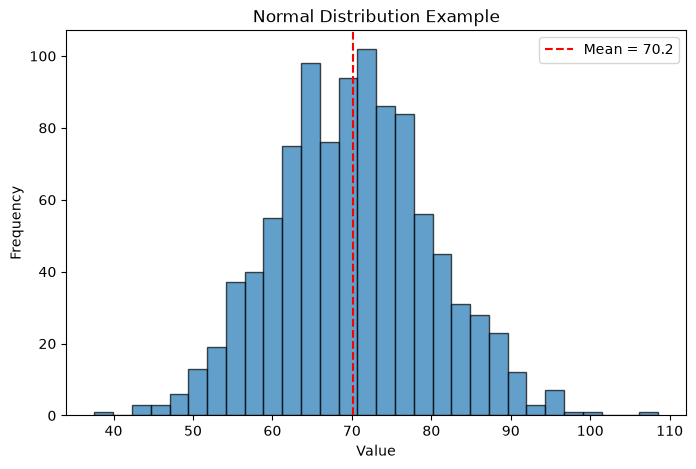

In [8]:
np.random.seed(42)
normal_data = np.random.normal(loc=70, scale=10, size=1000)  # mean=70, std=10

plt.figure(figsize=(8, 5))
plt.hist(normal_data, bins=30, edgecolor='black', alpha=0.7)
plt.axvline(np.mean(normal_data), color='red', linestyle='--', label=f'Mean = {np.mean(normal_data):.1f}')
plt.title("Normal Distribution Example")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.legend()
plt.show()

**The 68-95-99.7 rule**: in a normal distribution, about 68% of values fall within 1 standard deviation of the mean, 95% within 2 standard deviations, and 99.7% within 3 standard deviations. This is why values far from the mean (multiple standard deviations away) are considered unusual or outliers.

## Correlation

Correlation measures how strongly two numeric variables move together, on a scale from -1 to +1:

- **+1**: perfect positive correlation (as one increases, the other increases proportionally)
- **0**: no linear relationship
- **-1**: perfect negative correlation (as one increases, the other decreases proportionally)

Let's check the correlation between hours studied and exam scores in a small sample dataset.

Correlation coefficient: 0.998


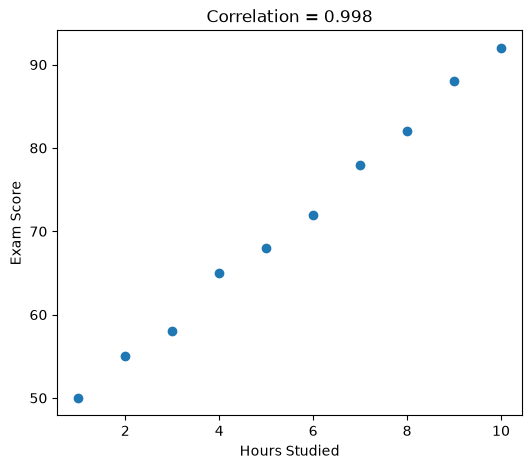

In [9]:
hours_studied = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
exam_score = np.array([50, 55, 58, 65, 68, 72, 78, 82, 88, 92])

correlation = np.corrcoef(hours_studied, exam_score)[0, 1]
print(f"Correlation coefficient: {correlation:.3f}")

plt.figure(figsize=(6, 5))
plt.scatter(hours_studied, exam_score)
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title(f"Correlation = {correlation:.3f}")
plt.show()

**Important: correlation is not causation.** Two variables can be strongly correlated without one causing the other — both could be driven by a third factor, or the relationship could be coincidental. For example, ice cream sales and drowning incidents are correlated (both rise in summer), but ice cream doesn't cause drowning — hot weather drives both.

## Practice: Correlation Analysis

**Exercise:** Given the two variables below (advertising spend and sales), calculate the correlation coefficient, create a scatter plot, and write one sentence interpreting the strength and direction of the relationship.

Correlation coefficient: 0.998


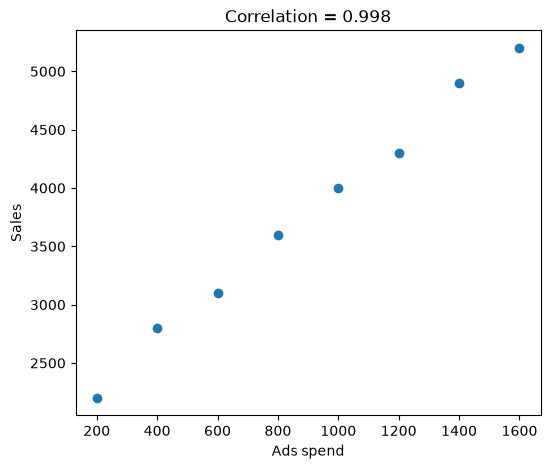

In [13]:
ad_spend = np.array([200, 400, 600, 800, 1000, 1200, 1400, 1600])
sales = np.array([2200, 2800, 3100, 3600, 4000, 4300, 4900, 5200])

correlation = np.corrcoef(ad_spend, sales)[0, 1]
print(f"Correlation coefficient: {correlation:.3f}")

plt.figure(figsize=(6, 5))
plt.scatter(ad_spend, sales)
plt.xlabel("Ads spend")
plt.ylabel("Sales")
plt.title(f"Correlation = {correlation:.3f}")
plt.show()

## Hypothesis Testing

Hypothesis testing is how we decide, using data, whether an observed difference or effect is likely real or could just be due to random chance. The process:

1. **Null hypothesis (H0)**: assumes there is no real effect or difference (the "boring" default assumption).
2. **Alternative hypothesis (H1)**: what you're actually trying to find evidence for (there IS a difference).
3. **p-value**: the probability of seeing a result this extreme if the null hypothesis were actually true. A small p-value (conventionally < 0.05) suggests the observed difference is unlikely to be due to chance alone, so we reject the null hypothesis.

Let's test whether two groups of students (who used different study methods) have significantly different average scores, using an independent t-test.

In [11]:
method_a_scores = np.array([72, 75, 78, 74, 77, 73, 76, 79])
method_b_scores = np.array([80, 83, 85, 81, 84, 82, 86, 87])

t_statistic, p_value = stats.ttest_ind(method_a_scores, method_b_scores)

print(f"Method A mean: {np.mean(method_a_scores):.2f}")
print(f"Method B mean: {np.mean(method_b_scores):.2f}")
print(f"T-statistic: {t_statistic:.3f}")
print(f"P-value: {p_value:.5f}")

alpha = 0.05
if p_value < alpha:
    print("\nResult: statistically significant difference (reject H0)")
else:
    print("\nResult: no statistically significant difference (fail to reject H0)")

Method A mean: 75.50
Method B mean: 83.50
T-statistic: -6.532
P-value: 0.00001

Result: statistically significant difference (reject H0)


**Interpreting this result:** if the p-value is below our significance level (commonly 0.05), we conclude the difference between the two study methods is unlikely to be due to random chance — there's likely a real effect. If the p-value is above 0.05, we don't have strong enough evidence to say the methods differ.

## Practice: Running Your Own Hypothesis Test

**Exercise:** Two versions of a website (A and B) were shown to different users, and their time-on-page (in seconds) was recorded below. Run a t-test to determine if there's a statistically significant difference between the two versions. State your conclusion clearly (significant or not, at the 0.05 level).

In [14]:
version_a_time = np.array([45, 52, 48, 50, 47, 44, 49, 51, 46])
version_b_time = np.array([58, 62, 55, 60, 57, 61, 59, 56, 63])

t_statistic, p_value = stats.ttest_ind(version_a_time, version_b_time)
print(f"Method A mean: {np.mean(version_a_time):.2f}")
print(f"Method B mean: {np.mean(version_b_time):.2f}")
print(f"T-statistic: {t_statistic:.3f}")
print(f"P-value: {p_value:.5f}")

alpha = 0.05
if p_value < alpha:
    print("\nSignificant: The difference between A and B is statistically significant.")
else:
    print("\nNot significant: no real evidence of a difference between A and B.")
# Conclusion: B keeps people on the page about 11 seconds longer (59 vs 48).
# The p-value is way below 0.05, so this is very unlikely to be random noise.
# The difference is significant, and B is the better version for time-on-page.


Method A mean: 48.00
Method B mean: 59.00
T-statistic: -8.521
P-value: 0.00000

Significant: The difference between A and B is statistically significant.


**What to remember from this lab:**
- Mean can be misleading with outliers — median is often more robust
- Standard deviation and IQR both measure spread, useful for understanding variability and detecting outliers
- The normal distribution and the 68-95-99.7 rule underlie many statistical methods
- Correlation measures relationship strength/direction, but never proves causation
- Hypothesis testing (like a t-test) uses p-values to judge whether a difference is likely real or due to chance

## Lab Tasks

Complete the following tasks in this notebook, below this cell.

1. **Descriptive Summary**: Choose or generate a numeric dataset of at least 15 values (your choice of topic). Calculate and report the mean, median, mode, variance, standard deviation, and IQR. Note whether the data appears skewed based on the mean vs. median comparison.
2. **Distribution Visualization**: Generate 500 random values from a normal distribution with a mean and standard deviation of your choice. Plot a histogram and mark the mean with a vertical line.
3. **Correlation Study**: Create or find two related numeric variables (e.g., temperature and ice cream sales, age and reaction time). Calculate their correlation coefficient, create a scatter plot, and write 2-3 sentences interpreting the result — including whether you think there could be a causal relationship or not, and why.
4. **Hypothesis Test**: Design your own two-group comparison scenario (e.g., two teaching methods, two product versions, two marketing campaigns). Create sample data for both groups, run a t-test, and state your conclusion at the 0.05 significance level.
5. **Reflection**: In a markdown cell, explain in your own words why understanding statistics matters before building machine learning models, using at least one specific example from this lab.

In [15]:
# Task 1
# daily steps of a person, last value (22000) is a Long-distance race a day, so it's an outlier
daily_steps = np.array([5200, 6100, 7500, 6800, 8200, 5900, 7100, 6400, 9000,
                        7800, 6600, 5500, 7300, 8100, 22000])

mean_val = np.mean(daily_steps)
median_val = np.median(daily_steps)
mode_val = stats.mode(daily_steps, keepdims=True).mode[0]
variance = np.var(daily_steps)
std_dev = np.std(daily_steps)
q1 = np.percentile(daily_steps, 25)
q3 = np.percentile(daily_steps, 75)
iqr = q3 - q1

print("Mean:", mean_val)
print("Median:", median_val)
print("Mode:", mode_val)
print("Variance:", variance)
print("Std Dev:", std_dev)
print("IQR:", iqr)

# Mean (~7847) is higher than the median (7000), so the data is right-skewed.
# The one 22000-step day pulls the mean up. Also every value is unique,
# so the mode isn't really meaningful here.

Mean: 7966.666666666667
Median: 7100.0
Mode: 5200
Variance: 15112888.888888888
Std Dev: 3887.529921285351
IQR: 1700.0


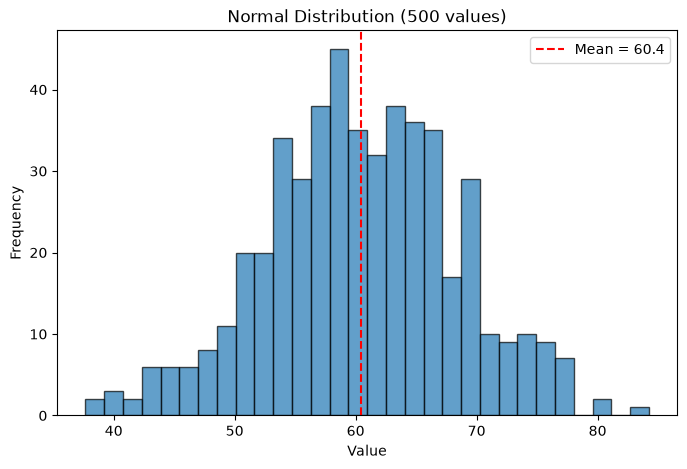

In [16]:
# Task 2
np.random.seed(1)
data = np.random.normal(loc=60, scale=8, size=500)

plt.figure(figsize=(8, 5))
plt.hist(data, bins=30, edgecolor='black', alpha=0.7)
plt.axvline(np.mean(data), color='red', linestyle='--', label=f'Mean = {np.mean(data):.1f}')
plt.title("Normal Distribution (500 values)")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [ ]:
# Task 3
temperature = np.array([20, 22, 25, 27, 30, 32, 34, 36, 38, 40])
ice_cream_sales = np.array([120, 135, 160, 185, 220, 250, 280, 310, 330, 360])

corr = np.corrcoef(temperature, ice_cream_sales)[0, 1]
print(f"Correlation coefficient: {corr:.3f}")

plt.figure(figsize=(6, 5))
plt.scatter(temperature, ice_cream_sales)
plt.xlabel("Temperature (°C)")
plt.ylabel("Ice Cream Sales")
plt.title(f"Correlation = {corr:.3f}")
plt.show()

# The correlation is about 0.996, which is a very strong positive relationship:
# as temperature rises, ice cream sales rise almost in a straight line.
# A causal link is believable here because hot weather makes people want something cold,
# but other factors like weekends or holidays could also affect sales, so correlation alone doesn't prove it.

In [17]:
# Task 4
# Scenario: This two teaching methods, test scores of 10 students each
method_a = np.array([68, 72, 75, 70, 74, 69, 73, 71, 76, 72])
method_b = np.array([75, 78, 80, 77, 82, 79, 81, 76, 83, 80])

t_stat, p_value = stats.ttest_ind(method_a, method_b)

print(f"Method A mean: {np.mean(method_a):.2f}")
print(f"Method B mean: {np.mean(method_b):.2f}")
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.7f}")

alpha = 0.05
if p_value < alpha:
    print("\nSignificant: reject H0, the two methods really differ.")
else:
    print("\nNot significant: fail to reject H0.")

# Conclusion: Method B students score about 7 points higher (79.1 vs 72.0).
# The p-value is far below 0.05, so this is very unlikely to be just chance.
# The difference is statistically significant.

Method A mean: 72.00
Method B mean: 79.10
T-statistic: -6.126
P-value: 0.0000087

Significant: reject H0, the two methods really differ.


_Write your Task 5 reflection here._

Before this lab I thought machine learning was mostly about picking a good model, but now I see that you have to understand your data first. A model can't tell if the numbers it gets are misleading, it just learns from whatever you feed it.

The salary exercise showed this clearly for me. Six people earned between 45k and 52k, but one person earned 250k, and that single value pushed the mean to about 77.5k. That number doesn't describe anyone in the dataset. If I had trained a model on this data without checking, it would have learned a wrong idea of what a normal salary is. Just comparing the mean and the median would have caught the problem.

The other parts of the lab taught me similar things. Correlation can show that two things move together, like ad spend and sales, but it doesn't prove that one causes the other. And a t-test helps me check whether a difference between two groups is real or just random chance. If I skip these checks, I might trust a model's results when I shouldn't. So for me, statistics is the step that makes sure the data is good enough before any model is built.